# ConvTransformer para detección de puntos de cambio en trayectorias de difusión anómala

Este cuaderno presenta el experimento final con una arquitectura ConvTransformer para estimar la posición del punto de cambio en trayectorias sintéticas de difusión anómala. El protocolo utiliza la base completa, trayectorias de longitud fija 100, un único punto de cambio y una longitud mínima de 20 puntos por segmento.

La entrada del modelo se construye a partir de la trayectoria y de sus incrementos para aportar información local sobre la dinámica antes y después del cambio.

## 1. Importación de librerías

Se cargan las librerías necesarias para manipular los datos HDF5, preparar las trayectorias, construir la red neuronal, entrenarla y generar las visualizaciones de evaluación.

In [1]:
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import callbacks, layers, metrics, models, optimizers
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.21.0
GPU available: False


## 2. Configuración experimental

Se fija la configuración final de la experiencia: uso de la base completa, longitud de trayectoria igual a 100, punto de cambio único y segmentos con al menos 20 puntos. El modo rápido queda desactivado para trabajar con todos los datos disponibles.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

LENGTH = 100
MIN_SEGMENT_LENGTH = 20

MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
TRANSITIONS = [(m1, m2) for m1 in MODELS for m2 in MODELS if m1 != m2]

# En ejecución final, FAST_RUN = False.
# Para una prueba rápida en CPU, se puede poner FAST_RUN = True.
FAST_RUN = False

FAST_TRAIN_SIZE = 200000
FAST_VAL_SIZE = 20000
FAST_TEST_SIZE = 200000

EPOCHS = 80
BATCH_SIZE = 256
PREDICT_BATCH_SIZE = 2048

MODEL_DIM = 64
NUM_HEADS = 4
FEEDFORWARD_DIM = 128
NUM_TRANSFORMER_BLOCKS = 3
DROPOUT_RATE = 0.15

DATA_DIR = Path("C:/Users/chair/Downloads/data_synthetic_changepoint_andi")
OUTPUT_DIR = Path("convtransformer_results_final")
OUTPUT_DIR.mkdir(exist_ok=True)

VALID_CUTS = np.arange(MIN_SEGMENT_LENGTH, LENGTH - MIN_SEGMENT_LENGTH + 1)
N_VALID_CUTS = len(VALID_CUTS)

print("Valid cuts:", VALID_CUTS[0], "to", VALID_CUTS[-1])
print("Number of valid cuts:", N_VALID_CUTS)

Valid cuts: 20 to 80
Number of valid cuts: 61


## 3. Carga de la base sintética

La base sintética se almacena en archivos HDF5. Cada subconjunto contiene las trayectorias `X`, el punto de cambio real `cp`, los modelos de difusión de los dos segmentos, los exponentes anómalos y el nivel de ruido. En esta sección se cargan los datos y se normaliza cada trayectoria de forma individual.

In [3]:
MODEL_MAP = {
    0: "ATTM",
    1: "CTRW",
    2: "FBM",
    3: "LW",
    4: "SBM"
}


def decode_model_values(values):
    decoded = []
    for value in values:
        if isinstance(value, bytes):
            value = value.decode("utf-8")
        try:
            decoded.append(MODEL_MAP[int(value)])
        except Exception:
            decoded.append(str(value).replace("b'", "").replace("'", "").strip().upper())
    return decoded


def load_split(split_name):
    h5_path = DATA_DIR / f"{split_name}_L100_dim1.h5"

    with h5py.File(h5_path, "r") as file:
        x = file["X"][:].astype("float32")
        positions = file["cp"][:].astype("float32")
        model1 = decode_model_values(file["model1"][:])
        model2 = decode_model_values(file["model2"][:])
        alpha1 = file["alpha1"][:]
        alpha2 = file["alpha2"][:]
        noise_sigma = file["noise_sigma"][:]

    if x.ndim == 2:
        x = x[:, :, None]

    # Normalización por trayectoria sobre la posición original.
    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)
    y = (positions / LENGTH).astype("float32")

    metadata = pd.DataFrame({
        "cp": positions,
        "model1": model1,
        "model2": model2,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "noise_sigma": noise_sigma
    })

    metadata["transition"] = metadata["model1"] + " → " + metadata["model2"]

    return x, positions, y, metadata


def balanced_fast_subset(x, positions, y, metadata, total_size, seed=42):
    rng = np.random.default_rng(seed)
    groups = metadata.groupby(["model1", "model2"]).indices
    per_group = max(1, total_size // len(groups))
    selected_indices = []

    for indices in groups.values():
        indices = np.array(list(indices))
        size = min(per_group, len(indices))
        selected_indices.extend(rng.choice(indices, size=size, replace=False))

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return (
        x[selected_indices],
        positions[selected_indices],
        y[selected_indices],
        metadata.iloc[selected_indices].reset_index(drop=True)
    )

## 4. Preparación de entrenamiento, validación y prueba

Se cargan los conjuntos de entrenamiento, validación y prueba. Para cada trayectoria se construyen cuatro canales de entrada: posición `x(t)`, incremento `dx(t)`, valor absoluto `|dx(t)|` y energía local `dx(t)^2`. Esta representación permite que el modelo observe tanto la evolución de la posición como los cambios locales en la dinámica.

In [4]:
x_train_raw, train_positions, y_train, train_metadata = load_split("train")
x_val_raw, val_positions, y_val, val_metadata = load_split("val")
x_test_raw, test_positions, y_test, test_metadata = load_split("test")

if FAST_RUN:
    x_train_raw, train_positions, y_train, train_metadata = balanced_fast_subset(
        x_train_raw, train_positions, y_train, train_metadata, FAST_TRAIN_SIZE, SEED
    )
    x_val_raw, val_positions, y_val, val_metadata = balanced_fast_subset(
        x_val_raw, val_positions, y_val, val_metadata, FAST_VAL_SIZE, SEED
    )
    x_test_raw, test_positions, y_test, test_metadata = balanced_fast_subset(
        x_test_raw, test_positions, y_test, test_metadata, FAST_TEST_SIZE, SEED
    )


def make_features(x):
    # Construye cuatro canales informativos: x(t), dx(t), |dx(t)| y dx(t)^2.
    position = x[:, :, 0]
    dx = np.diff(position, axis=1, prepend=position[:, :1])
    abs_dx = np.abs(dx)
    dx2 = dx ** 2

    features = np.stack([position, dx, abs_dx, dx2], axis=-1)

    # Normalización por trayectoria y por canal.
    features = (
        features - features.mean(axis=1, keepdims=True)
    ) / (
        features.std(axis=1, keepdims=True) + 1e-8
    )

    return features.astype("float32")


# Entradas finales del modelo: (N, 100, 4)
x_train = make_features(x_train_raw)
x_val = make_features(x_val_raw)
x_test = make_features(x_test_raw)

split_size_frame = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "trajectories": [len(x_train), len(x_val), len(x_test)],
    "raw_shape": [x_train_raw.shape, x_val_raw.shape, x_test_raw.shape],
    "model_input_shape": [x_train.shape, x_val.shape, x_test.shape]
})

display(split_size_frame)
display(test_metadata["transition"].value_counts().sort_index())

,split,trajectories,raw_shape,model_input_shape
0,train,200000,"(200000, 100, 1)","(200000, 100, 4)"
1,validation,20000,"(20000, 100, 1)","(20000, 100, 4)"
2,test,200000,"(200000, 100, 1)","(200000, 100, 4)"


transition
ATTM → CTRW    10000
ATTM → FBM     10000
ATTM → LW      10000
ATTM → SBM     10000
CTRW → ATTM    10000
CTRW → FBM     10000
CTRW → LW      10000
CTRW → SBM     10000
FBM → ATTM     10000
FBM → CTRW     10000
FBM → LW       10000
FBM → SBM      10000
LW → ATTM      10000
LW → CTRW      10000
LW → FBM       10000
LW → SBM       10000
SBM → ATTM     10000
SBM → CTRW     10000
SBM → FBM      10000
SBM → LW       10000
Name: count, dtype: int64

## 5. Visualización inicial de trayectorias

Se muestran trayectorias aleatorias con su transición y su punto de cambio real. Esta comprobación permite verificar visualmente que los datos están correctamente cargados antes de entrenar el modelo.

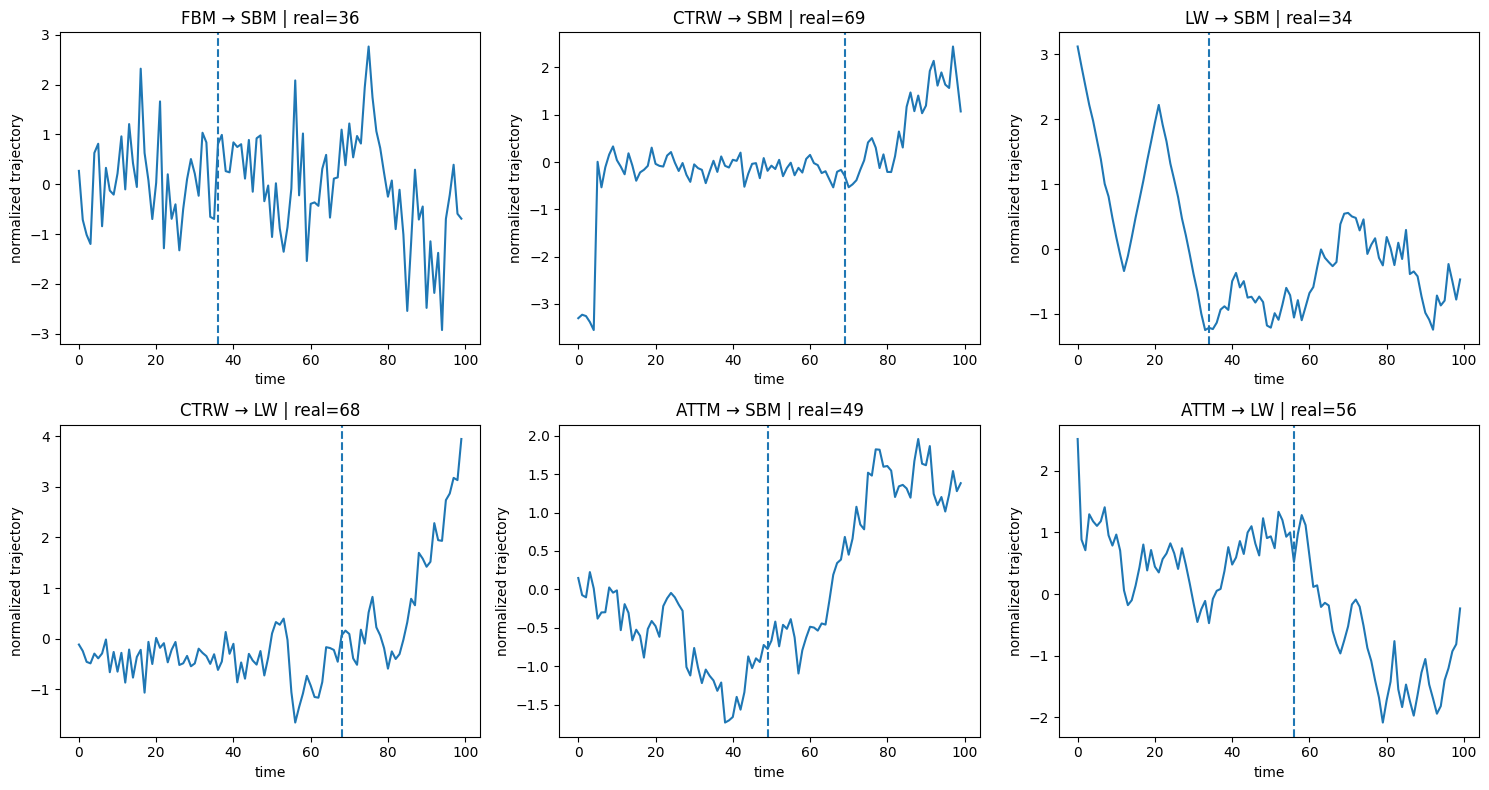

In [5]:
def plot_examples(x_raw, positions, metadata, n_examples=6):
    n_examples = min(n_examples, len(x_raw))
    selected = np.random.choice(len(x_raw), size=n_examples, replace=False)
    columns = 3
    rows = int(np.ceil(n_examples / columns))

    plt.figure(figsize=(15, 4 * rows))

    for panel, index in enumerate(selected, start=1):
        plt.subplot(rows, columns, panel)
        plt.plot(x_raw[index, :, 0])
        plt.axvline(int(positions[index]), linestyle="--")
        plt.title(f"{metadata.iloc[index]['transition']} | real={int(positions[index])}")
        plt.xlabel("time")
        plt.ylabel("normalized trajectory")

    plt.tight_layout()
    plt.show()


plot_examples(x_train_raw, train_positions, train_metadata)

## 6. Construcción del modelo ConvTransformer

El modelo ConvTransformer combina extracción local de patrones y mecanismos de atención. Primero, los cuatro canales de entrada se proyectan a una representación latente. Después se añade una codificación posicional aprendible para conservar la información del orden temporal.

La parte convolucional permite capturar variaciones cercanas dentro de la trayectoria, mientras que los bloques Transformer comparan regiones más alejadas entre sí. Finalmente, el modelo calcula scores sobre las posiciones válidas del punto de cambio y obtiene una predicción continua mediante soft-argmax.

In [6]:
@tf.keras.utils.register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, model_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.model_dim = model_dim
        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=model_dim
        )

    def call(self, inputs):
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        return inputs + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "model_dim": self.model_dim,
        })
        return config


@tf.keras.utils.register_keras_serializable()
class SoftArgmaxCut(layers.Layer):
    def __init__(self, min_segment, length, **kwargs):
        super().__init__(**kwargs)
        self.min_segment = min_segment
        self.length = length
        self.valid_positions = tf.constant(
            np.arange(min_segment, length - min_segment + 1),
            dtype=tf.float32
        )

    def call(self, logits):
        # logits shape: (batch, number_of_valid_positions)
        probabilities = tf.nn.softmax(logits, axis=-1)
        expected_cut = tf.reduce_sum(probabilities * self.valid_positions, axis=-1)
        return expected_cut / tf.cast(self.length, tf.float32)

    def get_config(self):
        config = super().get_config()
        config.update({
            "min_segment": self.min_segment,
            "length": self.length,
        })
        return config


def transformer_encoder_block(inputs, model_dim, num_heads, feedforward_dim, dropout_rate):
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=model_dim // num_heads,
        dropout=dropout_rate
    )(inputs, inputs)

    x = layers.LayerNormalization(epsilon=1e-6)(
        inputs + layers.Dropout(dropout_rate)(attention_output)
    )

    feedforward_output = layers.Dense(feedforward_dim, activation="gelu")(x)
    feedforward_output = layers.Dropout(dropout_rate)(feedforward_output)
    feedforward_output = layers.Dense(model_dim)(feedforward_output)

    x = layers.LayerNormalization(epsilon=1e-6)(
        x + layers.Dropout(dropout_rate)(feedforward_output)
    )

    return x


def local_conv_block(inputs, model_dim, dropout_rate):
    residual = inputs

    x = layers.Conv1D(model_dim, kernel_size=5, padding="same")(inputs)
    x = layers.Activation("gelu")(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(model_dim, kernel_size=3, padding="same")(x)
    x = layers.Activation("gelu")(x)
    x = layers.Dropout(dropout_rate)(x)

    return layers.LayerNormalization(epsilon=1e-6)(residual + x)


def build_convtransformer_changepoint_model(
    input_shape,
    model_dim=MODEL_DIM,
    num_heads=NUM_HEADS,
    feedforward_dim=FEEDFORWARD_DIM,
    num_blocks=NUM_TRANSFORMER_BLOCKS,
    dropout_rate=DROPOUT_RATE
):
    inputs = layers.Input(shape=input_shape)

    # Proyección inicial suave desde los 4 canales: x, dx, |dx|, dx².
    x = layers.Dense(model_dim)(inputs)

    # Codificación posicional para conservar la información de localización temporal.
    x = PositionalEmbedding(input_shape[0], model_dim)(x)

    # Extracción local menos agresiva que Conv1D + ReLU.
    x = local_conv_block(x, model_dim, dropout_rate)

    # Bloques Transformer para comparar regiones antes y después del cambio.
    for _ in range(num_blocks):
        x = transformer_encoder_block(
            x,
            model_dim=model_dim,
            num_heads=num_heads,
            feedforward_dim=feedforward_dim,
            dropout_rate=dropout_rate
        )

    # En lugar de pooling global, se calcula un score temporal por posición.
    token_logits = layers.Dense(1)(x)
    token_logits = layers.Lambda(lambda t: tf.squeeze(t, axis=-1))(token_logits)

    # Solo se consideran puntos válidos entre 20 y 80.
    valid_logits = layers.Lambda(
        lambda t: t[:, MIN_SEGMENT_LENGTH:(LENGTH - MIN_SEGMENT_LENGTH + 1)]
    )(token_logits)

    # Soft-argmax: predicción continua del punto de corte, normalizada a [0, 1].
    outputs = SoftArgmaxCut(MIN_SEGMENT_LENGTH, LENGTH)(valid_logits)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="convtransformer_changepoint_regressor"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="mse",
        metrics=[metrics.MeanAbsoluteError(name="mae")]
    )

    return model


model = build_convtransformer_changepoint_model(input_shape=x_train.shape[1:])
model.summary()

Model: "convtransformer_changepoint_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 4)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 100, 64)           │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ positional_embedding          │ (None, 100, 64)           │           6,400 │ dense[0][0]                │
│ (PositionalEmbedding)         │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 100, 64)           │          20,544 │ positional_embedding[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 100, 64)           │               0 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 100, 64)           │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 100, 64)           │          12,352 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 100, 64)           │               0 │ conv1d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 100, 64)           │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 64)           │               0 │ positional_embedding[0][0… │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 100, 64)           │             128 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 100, 64)           │          16,640 │ layer_normalization[0][0], │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 100, 64)           │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 64)           │               0 │ layer_normalization[0][0], │
│                               │                           │                 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 100, 64)           │             12

 Total params: 140,225 (547.75 KB)

 Trainable params: 140,225 (547.75 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

El entrenamiento se realiza sobre la posición normalizada del punto de cambio. Se utiliza el error cuadrático medio como función de pérdida y el MAE de validación para seleccionar el mejor modelo.

Durante el entrenamiento se aplican parada temprana, reducción adaptativa del learning rate y guardado automático del mejor modelo. Esto permite conservar la versión con mejor rendimiento en validación sin modificar el protocolo final de evaluación.

In [7]:
early_stop = callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    mode="min",
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    mode="min",
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_convtransformer_changepoint.keras",
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=1
)

csv_logger = callbacks.CSVLogger(
    OUTPUT_DIR / "convtransformer_training_log.csv",
    append=False
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, model_checkpoint, csv_logger],
    verbose=1
)

Epoch 1/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0261 - mae: 0.1319      
Epoch 1: val_mae improved from None to 0.10594, saving model to convtransformer_results_final\best_convtransformer_changepoint.keras

Epoch 1: finished saving model to convtransformer_results_final\best_convtransformer_changepoint.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 920s 1s/step - loss: 0.0235 - mae: 0.1216 - val_loss: 0.0196 - val_mae: 0.1059 - learning_rate: 0.0010
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0194 - mae: 0.1051   
Epoch 2: val_mae improved from 0.10594 to 0.09142, saving model to convtransformer_results_final\best_convtransformer_changepoint.keras

Epoch 2: finished saving model to convtransformer_results_final\best_convtransformer_changepoint.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 953s 1s/step - loss: 0.0186 - mae: 0.1018 - val_loss: 0.0164 - val_mae: 0.0914 - learning_rate: 0.0010
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0168 - mae: 0.0943   
Epoch 3

## 8. Evolución del entrenamiento

Se representa la evolución de la pérdida y del error absoluto medio durante el entrenamiento. Para facilitar la interpretación, el MAE normalizado se transforma a puntos temporales multiplicándolo por la longitud de la trayectoria.

,epoch,loss,mae,val_loss,val_mae,learning_rate
57,57,0.010417,0.067147,0.013597,0.072317,0.00001
58,58,0.010426,0.067134,0.013573,0.072286,0.00001
59,59,0.010381,0.066954,0.013598,0.072331,0.00001
60,60,0.010394,0.067046,0.013613,0.072317,0.00001
61,61,0.010393,0.067060,0.013603,0.072324,0.00001


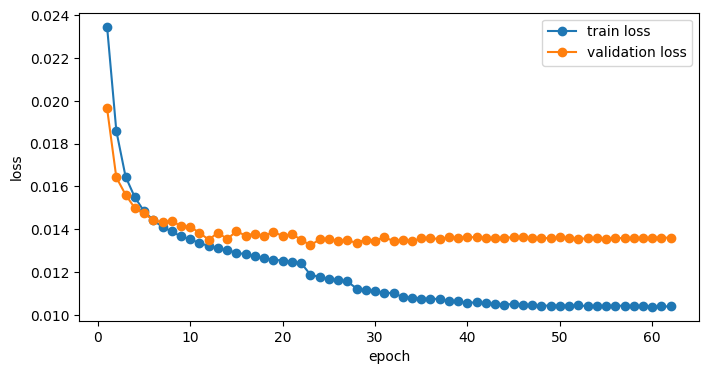

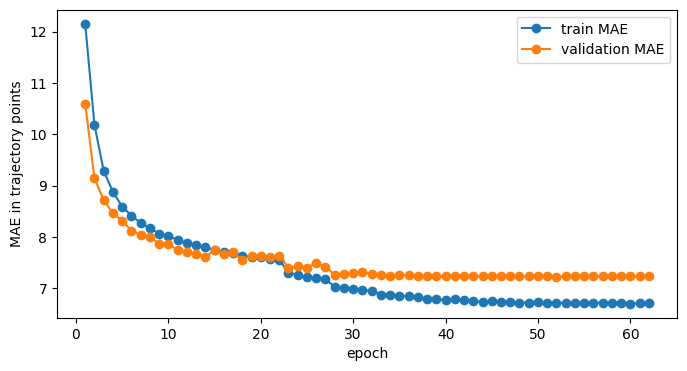

In [8]:
history_frame = pd.DataFrame(history.history)
history_frame.insert(0, "epoch", np.arange(len(history_frame)))

# Se añade la tasa de aprendizaje cuando está disponible.
if "learning_rate" not in history_frame.columns and "lr" in history_frame.columns:
    history_frame = history_frame.rename(columns={"lr": "learning_rate"})

display(history_frame.tail())

epochs_range = history_frame["epoch"] + 1

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["loss"], marker="o", label="train loss")
plt.plot(epochs_range, history_frame["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["mae"] * LENGTH, marker="o", label="train MAE")
plt.plot(epochs_range, history_frame["val_mae"] * LENGTH, marker="o", label="validation MAE")
plt.xlabel("epoch")
plt.ylabel("MAE in trajectory points")
plt.legend()
plt.show()

## 9. Diagnóstico de predicciones

Se analiza la distribución de las predicciones en validación para comprobar que el modelo no produce una salida casi constante. También se incluye una baseline que predice siempre la mediana del conjunto de entrenamiento.

In [9]:
predicted_val_normalized = model.predict(x_val, batch_size=PREDICT_BATCH_SIZE, verbose=0).reshape(-1)
predicted_val_positions = np.clip(predicted_val_normalized * LENGTH, MIN_SEGMENT_LENGTH, LENGTH - MIN_SEGMENT_LENGTH)

val_mae = mean_absolute_error(val_positions, predicted_val_positions)
val_rmse = np.sqrt(mean_squared_error(val_positions, predicted_val_positions))

baseline_position = np.median(train_positions)
baseline_predictions = np.full_like(val_positions, baseline_position, dtype=np.float32)
baseline_mae = mean_absolute_error(val_positions, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(val_positions, baseline_predictions))

diagnostic_frame = pd.DataFrame({
    "quantity": ["prediction_mean", "prediction_std", "prediction_min", "prediction_max", "validation_MAE", "validation_RMSE", "baseline_MAE", "baseline_RMSE"],
    "value": [
        predicted_val_positions.mean(),
        predicted_val_positions.std(),
        predicted_val_positions.min(),
        predicted_val_positions.max(),
        val_mae,
        val_rmse,
        baseline_mae,
        baseline_rmse
    ]
})

diagnostic_frame

,quantity,value
0,prediction_mean,49.968426
1,prediction_std,15.342903
2,prediction_min,20.373322
3,prediction_max,79.722168
4,validation_MAE,7.220756
5,validation_RMSE,11.640452
6,baseline_MAE,15.319750
7,baseline_RMSE,17.669096


## 10. Evaluación global en test

Las predicciones del modelo se convierten de valores normalizados a posiciones dentro de la trayectoria. A partir de ellas se calculan las métricas globales MAE y RMSE sobre el conjunto de prueba.

In [10]:
def predict_positions(model, x):
    predicted_normalized = model.predict(x, batch_size=PREDICT_BATCH_SIZE, verbose=0).reshape(-1)
    predicted_continuous = np.clip(
        predicted_normalized * LENGTH,
        MIN_SEGMENT_LENGTH,
        LENGTH - MIN_SEGMENT_LENGTH
    )
    predicted_positions = np.rint(predicted_continuous).astype(np.int32)
    predicted_positions = np.clip(predicted_positions, MIN_SEGMENT_LENGTH, LENGTH - MIN_SEGMENT_LENGTH)
    return predicted_positions, predicted_continuous, predicted_normalized


predicted_test_positions, predicted_test_continuous, predicted_test_normalized = predict_positions(model, x_test)

test_mae = mean_absolute_error(test_positions, predicted_test_positions)
test_rmse = np.sqrt(mean_squared_error(test_positions, predicted_test_positions))

test_mae_continuous = mean_absolute_error(test_positions, predicted_test_continuous)
test_rmse_continuous = np.sqrt(mean_squared_error(test_positions, predicted_test_continuous))

global_metrics = pd.DataFrame({
    "metric": ["MAE_rounded", "RMSE_rounded", "MAE_continuous", "RMSE_continuous"],
    "value_in_points": [test_mae, test_rmse, test_mae_continuous, test_rmse_continuous]
})

global_metrics

,metric,value_in_points
0,MAE_rounded,7.203850
1,RMSE_rounded,11.626196
2,MAE_continuous,7.214164
3,RMSE_continuous,11.622327


## 11. Resultados por pareja de modelos

Se calculan las métricas para cada transición ordenada entre modelos de difusión. Este análisis permite identificar las parejas de regímenes donde el punto de cambio es más fácil o más difícil de localizar.

In [11]:
result_frame = test_metadata.copy().reset_index(drop=True)
result_frame["true_changepoint"] = test_positions
result_frame["predicted_changepoint"] = predicted_test_positions
result_frame["predicted_changepoint_continuous"] = predicted_test_continuous
result_frame["error"] = result_frame["predicted_changepoint"] - result_frame["true_changepoint"]
result_frame["absolute_error"] = result_frame["error"].abs()
result_frame["predicted_normalized"] = predicted_test_normalized

pair_metrics = (
    result_frame
    .groupby(["model1", "model2"])
    .agg(
        samples=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        median_absolute_error=("absolute_error", "median"),
        mean_bias=("error", "mean")
    )
    .reset_index()
    .sort_values("mae")
)

pair_metrics["transition"] = pair_metrics["model1"] + " → " + pair_metrics["model2"]
pair_metrics = pair_metrics[["transition", "model1", "model2", "samples", "mae", "rmse", "median_absolute_error", "mean_bias"]]

pair_metrics

,transition,model1,model2,samples,mae,rmse,median_absolute_error,mean_bias
6,CTRW → LW,CTRW,LW,10000,2.6138,5.232648,1.0,-0.0180
13,LW → CTRW,LW,CTRW,10000,2.9581,5.695059,1.0,-0.3559
2,ATTM → LW,ATTM,LW,10000,4.4349,8.225236,2.0,-0.1949
12,LW → ATTM,LW,ATTM,10000,4.9101,8.699523,2.0,0.6905
15,LW → SBM,LW,SBM,10000,5.1645,9.091969,2.0,0.2799
19,SBM → LW,SBM,LW,10000,5.4515,9.433085,2.0,-0.6251
10,FBM → LW,FBM,LW,10000,5.5607,9.787865,2.0,-0.6559
14,LW → FBM,LW,FBM,10000,5.6287,10.061297,2.0,0.6721
7,CTRW → SBM,CTRW,SBM,10000,5.9340,9.924152,3.0,1.6566
5,CTRW → FBM,CTRW,FBM,10000,5.9612,10.316637,2.0,1.0406


## 12. Mapa de error por transición

El mapa resume el MAE por transición ordenada. Las filas representan el modelo del primer segmento y las columnas el modelo del segundo segmento.

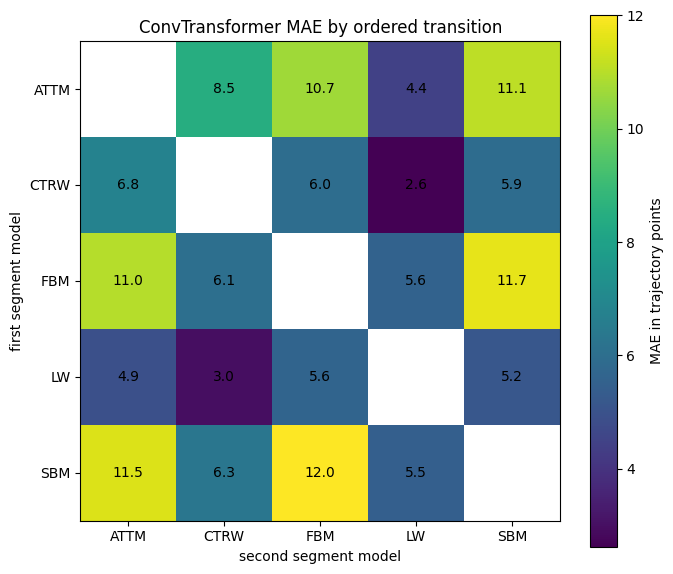

In [12]:
heatmap = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)

for _, row in pair_metrics.iterrows():
    if row["model1"] in MODELS and row["model2"] in MODELS:
        heatmap.loc[row["model1"], row["model2"]] = row["mae"]

plt.figure(figsize=(7, 6))
plt.imshow(heatmap.values.astype(float))
plt.xticks(range(len(MODELS)), MODELS)
plt.yticks(range(len(MODELS)), MODELS)
plt.xlabel("second segment model")
plt.ylabel("first segment model")
plt.title("ConvTransformer MAE by ordered transition")
plt.colorbar(label="MAE in trajectory points")

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        value = heatmap.iloc[i, j]
        if np.isfinite(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 13. Panel con puntos reales y predichos

Se selecciona una trayectoria representativa para cada transición y se muestran simultáneamente el punto de cambio real y el punto estimado por el modelo.

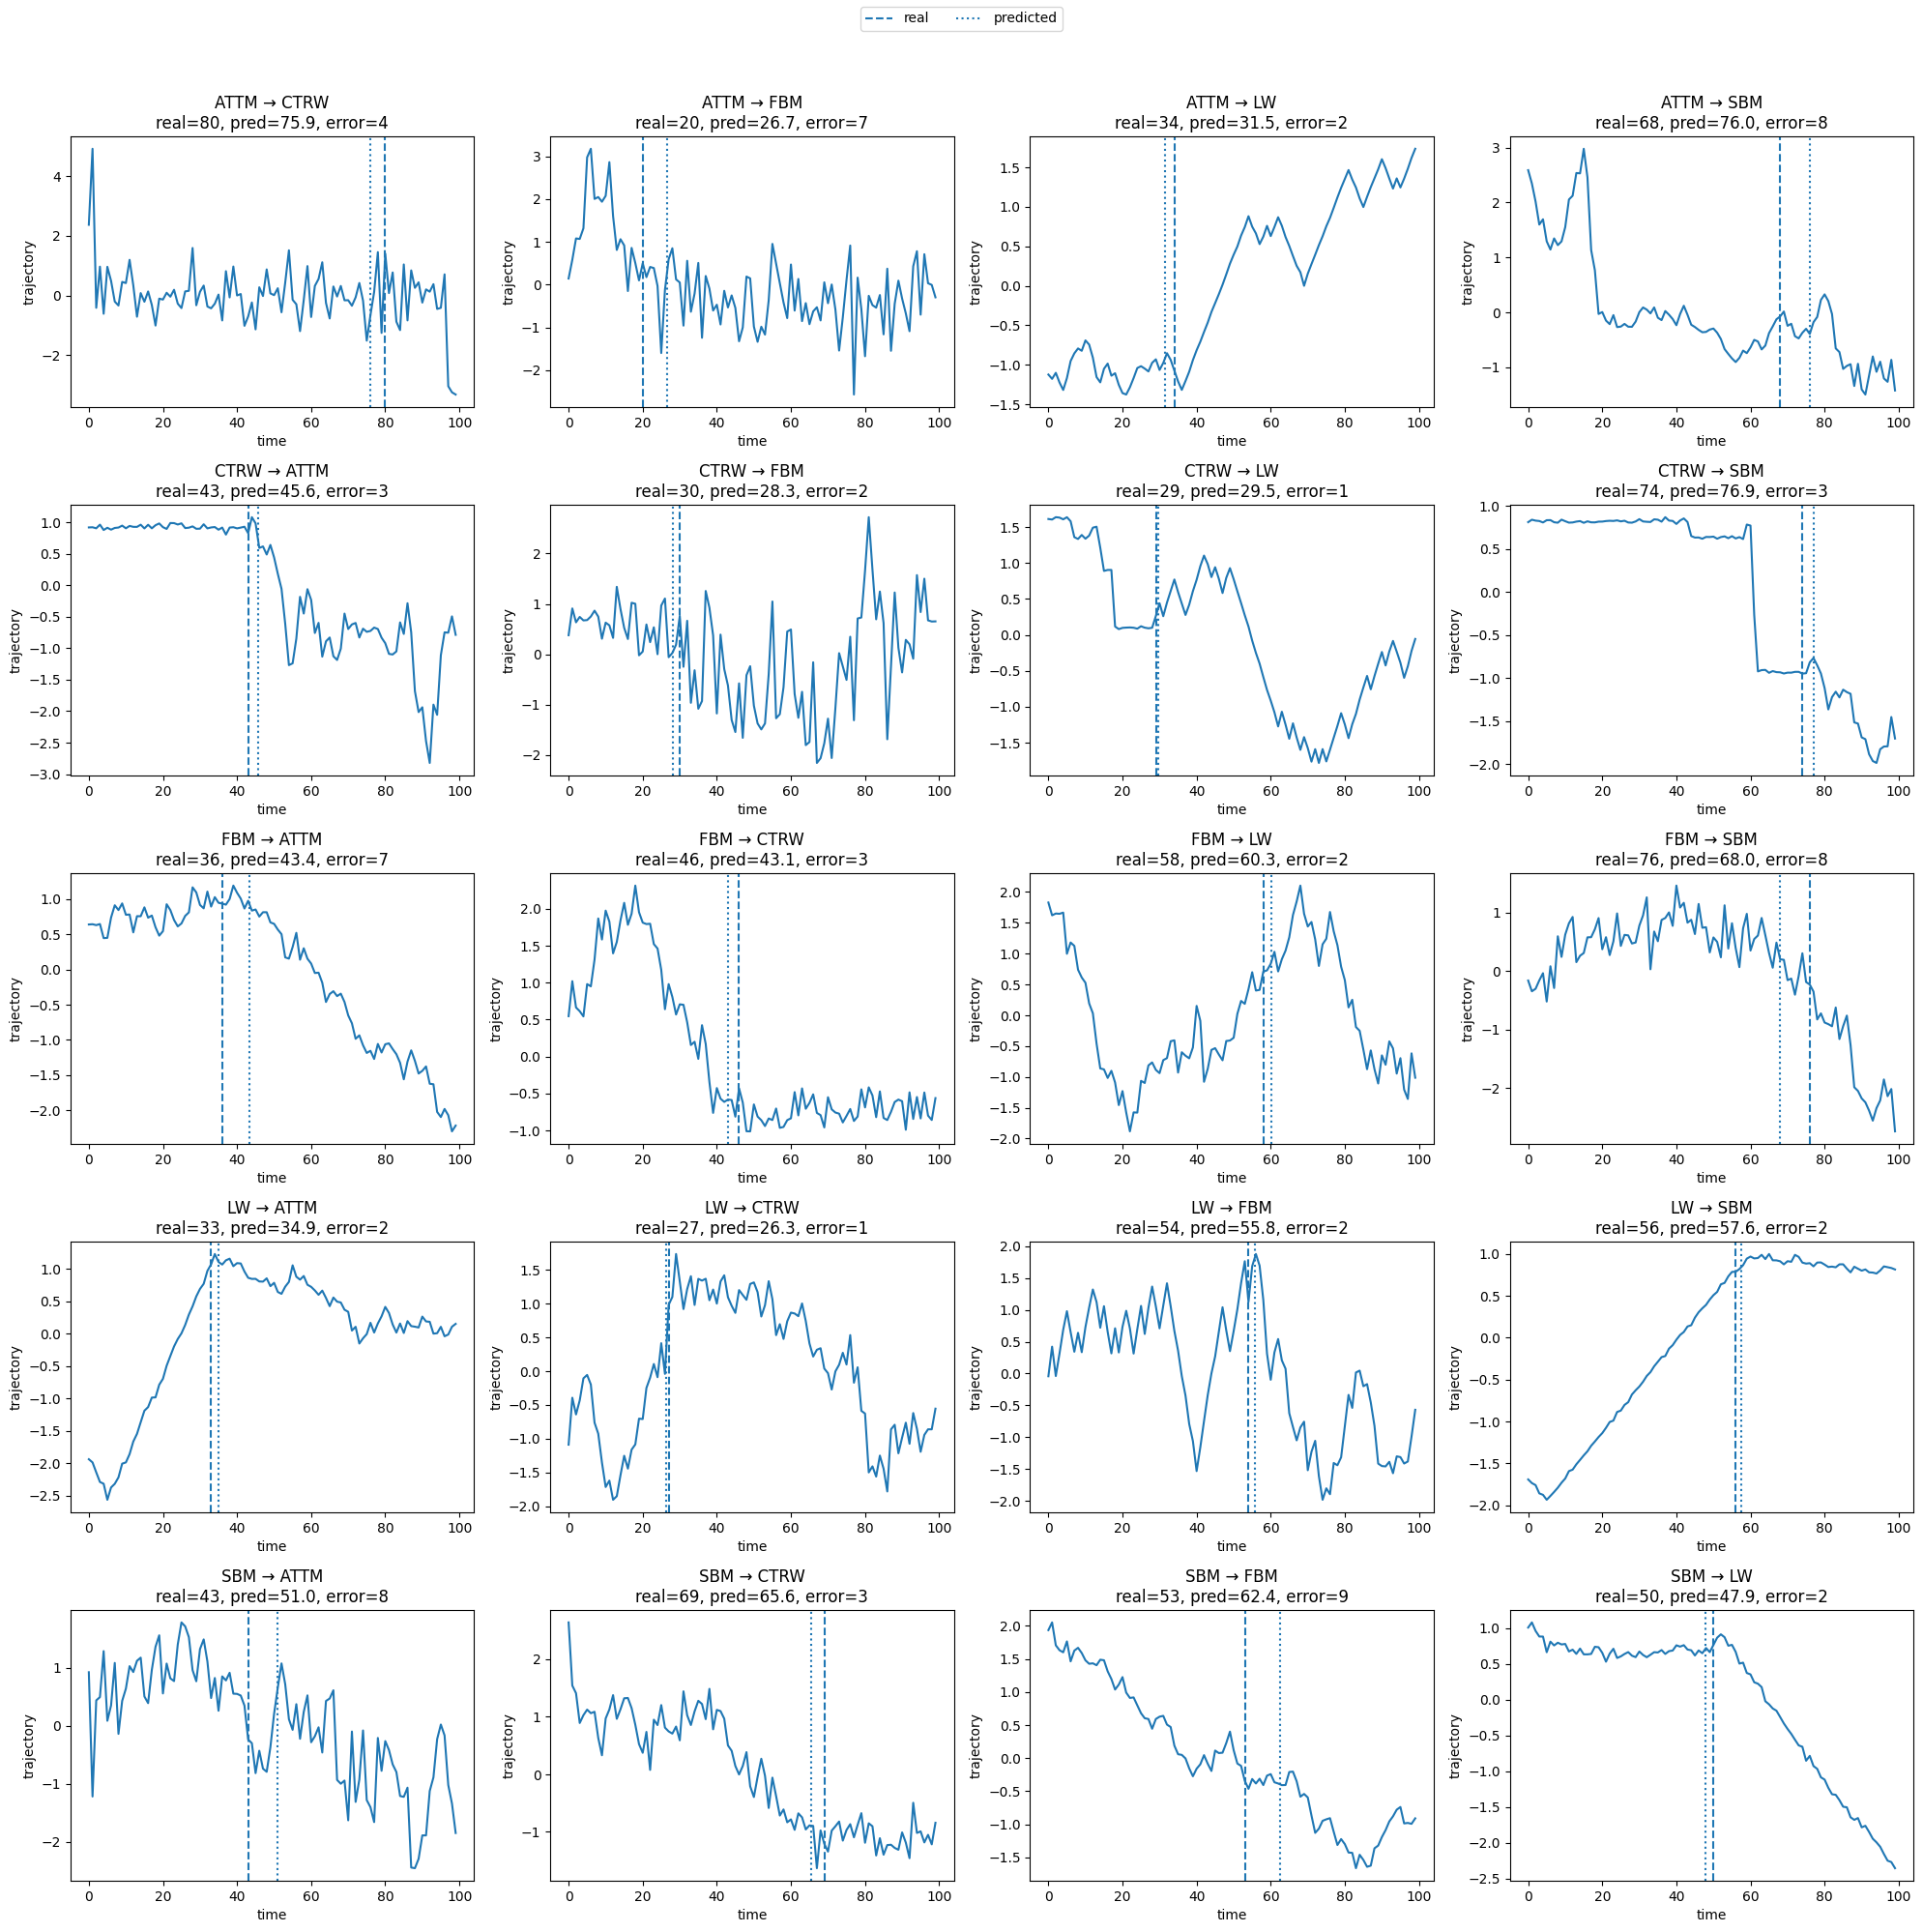

In [13]:
def representative_index_for_pair(frame, model1, model2):
    candidates = frame[(frame["model1"] == model1) & (frame["model2"] == model2)]

    if candidates.empty:
        return None

    target_error = candidates["absolute_error"].median()
    distances = (candidates["absolute_error"] - target_error).abs()

    return int(distances.idxmin())


def plot_transition_panel(x_raw, results, max_pairs=20):
    selected_pairs = TRANSITIONS[:max_pairs]
    columns = 4
    rows = int(np.ceil(len(selected_pairs) / columns))

    plt.figure(figsize=(20, 4 * rows))

    for panel_index, (model1, model2) in enumerate(selected_pairs, start=1):
        index = representative_index_for_pair(results, model1, model2)
        plt.subplot(rows, columns, panel_index)

        if index is None:
            plt.title(f"{model1} → {model2}\nno data")
            plt.axis("off")
            continue

        values = x_raw[index, :, 0]
        real_position = int(results.loc[index, "true_changepoint"])
        predicted_position = float(results.loc[index, "predicted_changepoint_continuous"])
        absolute_error = float(results.loc[index, "absolute_error"])

        plt.plot(values)
        plt.axvline(real_position, linestyle="--", label="real")
        plt.axvline(predicted_position, linestyle=":", label="predicted")

        plt.title(
            f"{model1} → {model2}\n"
            f"real={real_position}, pred={predicted_position:.1f}, error={absolute_error:.0f}"
        )

        plt.xlabel("time")
        plt.ylabel("trajectory")

    handles, labels = plt.gca().get_legend_handles_labels()

    if handles:
        plt.figlegend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_transition_panel(x_test_raw, result_frame)

## 14. Guardado de resultados

Se guardan las métricas globales, los resultados por transición, las predicciones del conjunto de test, el historial de entrenamiento y el modelo entrenado.

In [14]:
global_metrics.to_csv(OUTPUT_DIR / "convtransformer_global_metrics.csv", index=False)
pair_metrics.to_csv(OUTPUT_DIR / "convtransformer_pair_metrics.csv", index=False)
result_frame.to_csv(OUTPUT_DIR / "convtransformer_test_predictions.csv", index=False)
history_frame.to_csv(OUTPUT_DIR / "convtransformer_training_history.csv", index=False)
model.save(OUTPUT_DIR / "convtransformer_changepoint_final.keras")

print("Results saved in:", OUTPUT_DIR)

Results saved in: convtransformer_results_final


## 15. Conclusión

El modelo ConvTransformer fue aplicado a trayectorias sintéticas de longitud **L = 100**, formadas por dos fragmentos con modelos de difusión diferentes. El objetivo fue estimar la posición temporal donde ocurre el cambio entre ambos segmentos.

En esta arquitectura, la entrada no utiliza solo la trayectoria normalizada, sino también información local derivada de ella. Para cada trayectoria se construyen cuatro canales: la posición `x(t)`, el incremento `dx(t)`, el valor absoluto `|dx(t)|` y la energía local `dx(t)^2`. Esta representación permite combinar la evolución global de la señal con cambios locales en la dinámica.

La ejecución final se realizó con `FAST_RUN = False`, utilizando **200.000 trayectorias para entrenamiento**, **20.000 para validación** y **200.000 para prueba**. El conjunto de test está equilibrado con **10.000 trayectorias para cada una de las 20 transiciones ordenadas** entre modelos de difusión.

Los resultados globales muestran un **MAE = 7.20** y un **RMSE = 11.63** puntos temporales. Esto indica que el modelo localiza el punto de cambio con un error medio cercano a siete posiciones dentro de trayectorias cortas.

El análisis por transición muestra que el rendimiento no es igual para todas las parejas de modelos. Las transiciones **CTRW → LW** y **LW → CTRW** presentan los errores más bajos, mientras que combinaciones como **SBM → FBM**, **FBM → SBM**, **SBM → ATTM** y **ATTM → SBM** resultan más difíciles de identificar.

En general, el ConvTransformer ofrece un rendimiento sólido, combinando información local mediante convoluciones e incrementos con relaciones temporales más amplias mediante atención multi-cabeza.